# wm_plan.ipynb — Planification MPC dans l'espace latent

## Idée générale

Le LeWorldModel prédit le prochain état latent `z_{t+1}` depuis `z_t` et une action.
On va utiliser cette capacité pour **planifier** : à chaque pas, on demande au prédicteur
d'imaginer les 4 états suivants possibles, et on choisit l'action qui nous rapproche le plus
de l'objectif.

## Pourquoi la sonde linéaire pour mesurer la distance ?

Naïvement, on voudrait mesurer `||z_prédit - z_goal||₂` dans l'espace latent.
Mais le SIGReg force tous les embeddings vers N(0, I) : la position n'occupe que
2 directions sur 192, et les 190 autres dominent la distance L2.
Résultat : deux cases éloignées dans le jeu peuvent être proches en L2 dans R^192.

**La solution** : utiliser une sonde linéaire (Ridge regression) pour décoder `(col, row)`
depuis z, puis mesurer la distance dans l'espace physique.

```
┌─────────────────────────────────────────────────────┐
│  Boucle MPC fermée + distance probe-based           │
│                                                     │
│  obs_réelle ──[encoder]──► z_t                      │
│                                                     │
│  Pour chaque action a ∈ {haut, bas, gauche, droite}:│
│      ẑ_{t+1} = predictor(z_t, a)                   │
│      (col, row) = probe(ẑ_{t+1})                   │
│      score_a = dist_euclidienne((col,row), goal)    │
│                                                     │
│  a* = argmin score_a                                │
│  → exécuter a* dans le vrai environnement           │
│  → recommencer depuis le nouvel état réel           │
└─────────────────────────────────────────────────────┘
```

Le prédicteur imagine, la sonde décode, on planifie dans l'espace physique.

## 1. Config

In [35]:
from pathlib import Path

CHECKPOINT_PATH = Path("./saved_models/lewm_vit_50k_v4.pt")
DATASET_PATH    = Path("./local_runs/datasets/dataset_iso_N5_50k.npz")

MAX_STEPS  = 20   # nombre maximum de pas avant d'abandonner
GRID_SIZE  = 5

print(f"Checkpoint : {CHECKPOINT_PATH}  →  existe : {CHECKPOINT_PATH.exists()}")
print(f"Dataset    : {DATASET_PATH}  →  existe : {DATASET_PATH.exists()}")

Checkpoint : saved_models/lewm_vit_50k_v4.pt  →  existe : True
Dataset    : local_runs/datasets/dataset_iso_N5_50k.npz  →  existe : True


## 2. Imports

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

from src.model import LeWorldModel
from src.env import RenderConfig, precalculate_render, render_obs

ACTION_NAMES  = {0: "haut", 1: "bas", 2: "gauche", 3: "droite"}
# Deltas réels déduits des dynamiques apprises par le modèle :
# haut/bas agissent sur row (haut=row+1, bas=row-1) dans les coordonnées du dataset
ACTION_DELTAS = {0: (0, +1), 1: (0, -1), 2: (-1, 0), 3: (1, 0)}  # (dcol, drow)

print("Imports OK")

Imports OK


## 3. Chargement du modèle et du dataset

In [37]:
# Modèle
ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu")
cfg  = ckpt["config"]

model = LeWorldModel(
    img_size        = cfg["img_size"],
    patch_size      = cfg["patch_size"],
    embed_dim       = cfg["embed_dim"],
    encoder_depth   = cfg["encoder_depth"],
    predictor_depth = cfg["predictor_depth"],
    n_heads         = cfg["n_heads"],
    n_actions       = cfg["n_actions"],
)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Modèle chargé — {sum(p.numel() for p in model.parameters())/1e6:.2f}M paramètres")

# Dataset (pour trouver des observations réelles par position)
d       = np.load(DATASET_PATH)
obs_t   = d["obs_t"]    # (N, 128, 128) uint8
agent_t = d["agent_t"]  # (N, 2) — (col, row)
print(f"Dataset : {len(agent_t):,} transitions")

# Environnement
render_cfg   = RenderConfig()
render_cache = precalculate_render(render_cfg)
print("Environnement prêt")

Modèle chargé — 3.03M paramètres
Dataset : 50,000 transitions
Environnement prêt


## 4. Fonctions de base

Trois briques élémentaires :
- `encode_obs` : image → vecteur latent z
- `predict_next_z` : z + action → z prédit
- `apply_action` : position + action → nouvelle position réelle

In [38]:
def encode_obs(obs_np):
    """obs_np : (H, W) uint8  →  z : (D,) tensor"""
    x = torch.from_numpy(obs_np).float() / 255.0
    x = x.unsqueeze(0).unsqueeze(0)          # (1, 1, H, W)
    with torch.no_grad():
        z = model.encoder(x)                 # (1, D)
    return z.squeeze(0)                      # (D,)


def predict_next_z(z, action):
    """
    Prédit le prochain état latent (1 seul pas, sur un vrai embedding).
    z      : (D,) tensor — embedding réel sorti de l'encodeur
    action : int
    →        (D,) tensor — z prédit
    """
    act = torch.tensor([action])
    seq = z.unsqueeze(0).unsqueeze(0).expand(-1, 2, -1).clone()  # (1, 2, D)
    with torch.no_grad():
        pred = model.predictor(seq, act)     # (1, 2, D)
    return pred[0, 0]                        # (D,)


def apply_action(col, row, action):
    """Applique une action dans le vrai gridworld (avec gestion des bords)."""
    dcol, drow = ACTION_DELTAS[action]
    return (
        max(0, min(GRID_SIZE - 1, col + dcol)),
        max(0, min(GRID_SIZE - 1, row + drow)),
    )


def find_obs_for_pos(col, row):
    """Récupère une observation réelle depuis le dataset pour une position donnée."""
    mask = (agent_t[:, 0] == col) & (agent_t[:, 1] == row)
    idxs = np.where(mask)[0]
    assert len(idxs) > 0, f"Position ({col}, {row}) absente du dataset"
    return obs_t[idxs[0]]


print("Fonctions prêtes")

Fonctions prêtes


## 5. Vérification du prédicteur sur 1 pas

Avant de planifier, on vérifie que le prédicteur fonctionne bien sur **un seul pas**.

On encode l'état réel en (0,0), on prédit le prochain état avec chaque action,
et on compare avec l'embedding réel de l'état d'arrivée attendu.

In [39]:
print("Vérification 1-step : depuis (0, 0)")
print()

z_00 = encode_obs(find_obs_for_pos(0, 0))

for action in range(4):
    # Position réelle après l'action
    next_col, next_row = apply_action(0, 0, action)

    # Embedding prédit par le prédicteur
    z_pred = predict_next_z(z_00, action)

    # Embedding réel de l'état d'arrivée (depuis le dataset)
    z_real_next = encode_obs(find_obs_for_pos(next_col, next_row))

    # Distance entre prédit et réel
    dist = torch.norm(z_pred - z_real_next).item()

    print(f"  action={ACTION_NAMES[action]:6s}  →  ({next_col},{next_row})  "
          f"dist(z_pred, z_réel) = {dist:.4f}")

print()
print("Une distance faible = le prédicteur sait bien où on va.")

Vérification 1-step : depuis (0, 0)

  action=haut    →  (0,1)  dist(z_pred, z_réel) = 0.0793
  action=bas     →  (0,0)  dist(z_pred, z_réel) = 0.0681
  action=gauche  →  (0,0)  dist(z_pred, z_réel) = 0.0705
  action=droite  →  (1,0)  dist(z_pred, z_réel) = 0.1298

Une distance faible = le prédicteur sait bien où on va.


## 6. Entraînement de la sonde linéaire

On encode toutes les observations du dataset et on entraîne deux régressions Ridge :
- `probe_col` : z → colonne de l'agent
- `probe_row` : z → ligne de l'agent

Ces sondes permettent de décoder une position approximative depuis n'importe quel vecteur z,
y compris un z **prédit** par le prédicteur.

In [40]:
BATCH = 512

# Encodage de toutes les observations
print("Encodage du dataset...")
all_z = []
with torch.no_grad():
    for i in range(0, len(obs_t), BATCH):
        batch = torch.from_numpy(obs_t[i:i+BATCH]).float() / 255.0
        z = model.encoder(batch.unsqueeze(1))   # (B, D)
        all_z.append(z.numpy())
Z = np.concatenate(all_z, axis=0)              # (N, D)
print(f"Embeddings : {Z.shape}")

# Entraînement des sondes
probe_col = Ridge(alpha=1.0).fit(Z, agent_t[:, 0].astype(float))
probe_row = Ridge(alpha=1.0).fit(Z, agent_t[:, 1].astype(float))

r2_col = r2_score(agent_t[:, 0], probe_col.predict(Z))
r2_row = r2_score(agent_t[:, 1], probe_row.predict(Z))
print(f"Sonde col : R²={r2_col:.3f}")
print(f"Sonde row : R²={r2_row:.3f}")
print()
print("On peut maintenant décoder (col, row) depuis n'importe quel z.")


def decode_pos(z):
    """
    Décode la position (col, row) depuis un vecteur latent z.
    z : (D,) tensor ou np.array  →  (col_float, row_float)
    """
    z_np = z.numpy() if isinstance(z, torch.Tensor) else z
    col = probe_col.predict(z_np.reshape(1, -1))[0]
    row = probe_row.predict(z_np.reshape(1, -1))[0]
    return col, row


def probe_distance(z, goal_pos):
    """
    Distance physique entre la position décodée depuis z et l'objectif.
    z        : (D,) tensor
    goal_pos : (col, row) entiers
    →          float — distance euclidienne en cases
    """
    col_pred, row_pred = decode_pos(z)
    return np.sqrt((col_pred - goal_pos[0])**2 + (row_pred - goal_pos[1])**2)


# Vérification
z00 = encode_obs(find_obs_for_pos(0, 0))
z44 = encode_obs(find_obs_for_pos(4, 4))
print(f"decode(z(0,0)) = ({decode_pos(z00)[0]:.2f}, {decode_pos(z00)[1]:.2f})  attendu: (0, 0)")
print(f"decode(z(4,4)) = ({decode_pos(z44)[0]:.2f}, {decode_pos(z44)[1]:.2f})  attendu: (4, 4)")

Encodage du dataset...
Embeddings : (50000, 192)
Sonde col : R²=1.000
Sonde row : R²=0.990

On peut maintenant décoder (col, row) depuis n'importe quel z.
decode(z(0,0)) = (-0.06, 0.49)  attendu: (0, 0)
decode(z(4,4)) = (4.00, 4.00)  attendu: (4, 4)


/home/alexandre/anaconda3/envs/wm_colab/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.7049914308463485e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/alexandre/anaconda3/envs/wm_colab/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.7049914308463485e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


## 6. Choisir un état de départ et un objectif

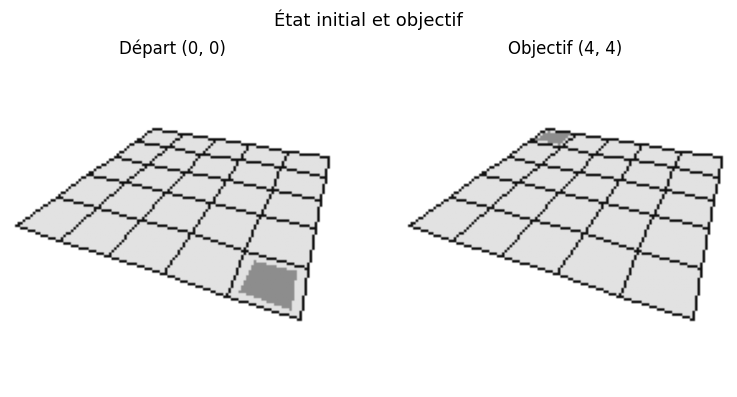

Distance latente initiale (départ → objectif) : 23.2027


In [41]:
START_POS = (0, 0)   # (col, row)
GOAL_POS  = (4, 4)

obs_start = find_obs_for_pos(*START_POS)
obs_goal  = find_obs_for_pos(*GOAL_POS)

z_goal = encode_obs(obs_goal)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(obs_start, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"Départ {START_POS}")
axes[0].axis("off")
axes[1].imshow(obs_goal, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Objectif {GOAL_POS}")
axes[1].axis("off")
plt.suptitle("État initial et objectif", fontsize=13)
plt.tight_layout()
plt.show()

z_start = encode_obs(obs_start)
print(f"Distance latente initiale (départ → objectif) : {torch.norm(z_goal - z_start):.4f}")

## 7. MPC en boucle fermée — distance probe-based

À chaque pas :
1. Encoder l'observation **réelle** courante → `z_t`
2. Pour chaque action : prédire `ẑ_{t+1}`, décoder `(col, row)` via la sonde, calculer la distance physique à l'objectif
3. Exécuter l'action avec le meilleur score
4. Recommencer depuis le nouvel état réel

In [42]:
def mpc_probe(start_pos, goal_pos, max_steps=MAX_STEPS, verbose=True):
    """
    MPC en boucle fermée avec distance probe-based.
    Retourne un dict avec la trajectoire complète.
    """
    col, row = start_pos
    traj = {
        "positions"   : [(col, row)],
        "actions"     : [],
        "decoded_pos" : [],    # position décodée du z prédit à chaque pas
        "scores"      : [],    # score probe de l'action choisie
        "all_scores"  : [],    # scores des 4 actions à chaque pas
    }

    for step in range(max_steps):
        if (col, row) == goal_pos:
            if verbose:
                print(f"  Objectif atteint en {step} pas !")
            break

        # Encoder l'état réel courant
        z_cur = encode_obs(find_obs_for_pos(col, row))

        # Évaluer les 4 actions avec la sonde
        scores = {}
        for a in range(4):
            z_pred    = predict_next_z(z_cur, a)
            scores[a] = probe_distance(z_pred, goal_pos)

        traj["all_scores"].append(scores)

        # Choisir la meilleure action
        best_action  = min(scores, key=scores.get)
        z_best       = predict_next_z(z_cur, best_action)
        col_d, row_d = decode_pos(z_best)

        # Exécuter dans le vrai environnement
        col, row = apply_action(col, row, best_action)

        traj["positions"].append((col, row))
        traj["actions"].append(best_action)
        traj["decoded_pos"].append((col_d, row_d))
        traj["scores"].append(scores[best_action])

    else:
        if (col, row) != goal_pos and verbose:
            print(f"  Limite de {max_steps} pas atteinte sans succès.")

    return traj


START_POS = (0, 0)
GOAL_POS  = (4, 4)

print(f"Planification : {START_POS} → {GOAL_POS}")
print()
traj = mpc_probe(START_POS, GOAL_POS)

print()
print("Trajectoire :")
print(f"  pas 0 : {traj['positions'][0]}")
for i, (action, pos) in enumerate(zip(traj["actions"], traj["positions"][1:]), start=1):
    col_d, row_d = traj["decoded_pos"][i-1]
    print(
        f"  pas {i} : {ACTION_NAMES[action]:6s} → réel={pos}  "
        f"prédit=({col_d:.1f},{row_d:.1f})  score={traj['scores'][i-1]:.3f}"
    )

success = traj["positions"][-1] == GOAL_POS
print()
print(f"Résultat : {'SUCCÈS ✓' if success else 'ÉCHEC ✗'}")

Planification : (0, 0) → (4, 4)

  Objectif atteint en 8 pas !

Trajectoire :
  pas 0 : (0, 0)
  pas 1 : droite → réel=(1, 0)  prédit=(1.0,0.7)  score=4.480
  pas 2 : droite → réel=(2, 0)  prédit=(2.0,0.1)  score=4.334
  pas 3 : haut   → réel=(2, 1)  prédit=(2.0,1.1)  score=3.476
  pas 4 : haut   → réel=(2, 2)  prédit=(2.0,1.9)  score=2.908
  pas 5 : haut   → réel=(2, 3)  prédit=(2.0,3.1)  score=2.149
  pas 6 : droite → réel=(3, 3)  prédit=(3.0,3.0)  score=1.377
  pas 7 : droite → réel=(4, 3)  prédit=(4.0,3.0)  score=0.980
  pas 8 : haut   → réel=(4, 4)  prédit=(4.0,4.0)  score=0.048

Résultat : SUCCÈS ✓


## 8. Visualisation de la trajectoire

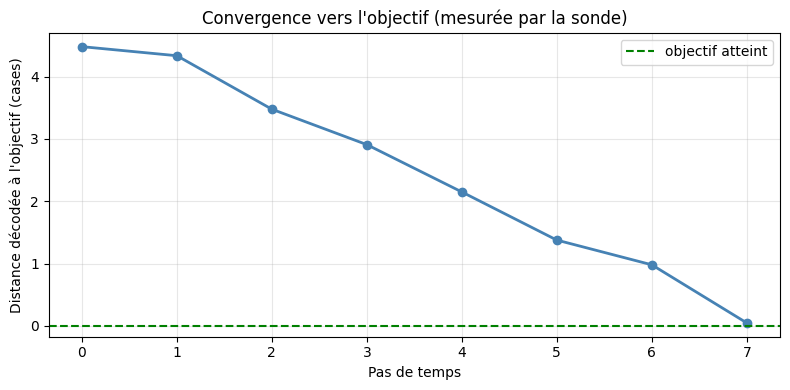

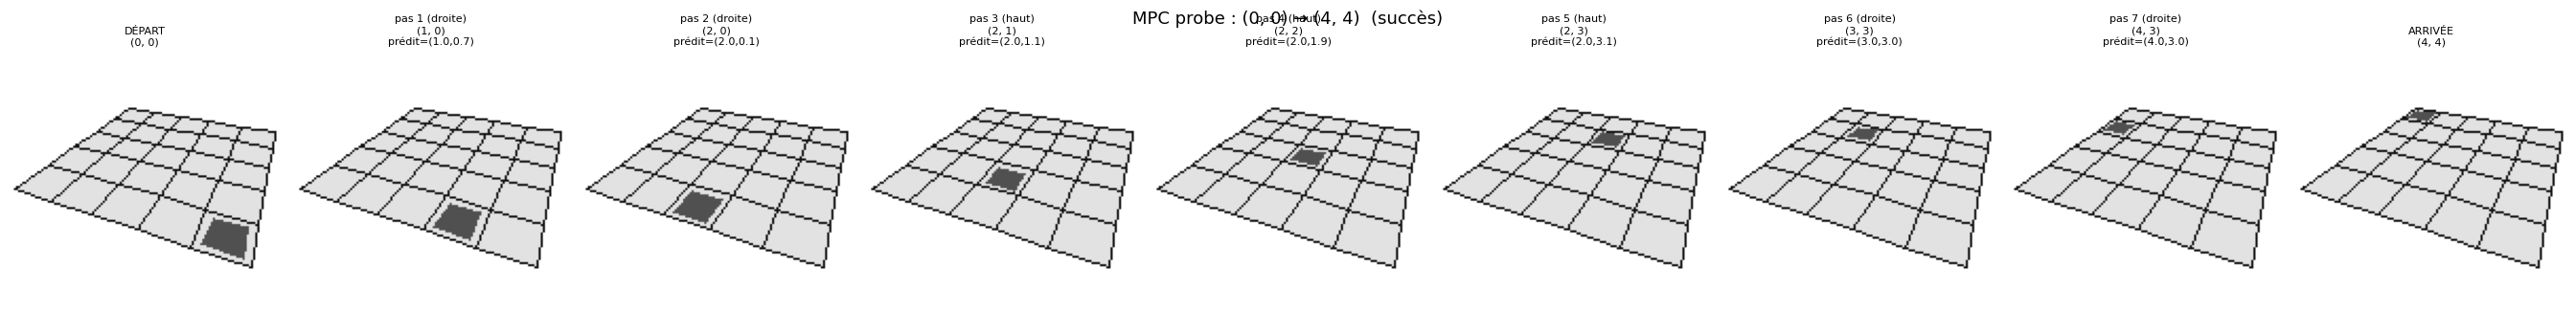

In [43]:
# Courbe du score probe au fil du temps
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(traj["scores"], marker="o", linewidth=2, color="steelblue")
ax.axhline(0, color="green", linestyle="--", label="objectif atteint")
ax.set_xlabel("Pas de temps")
ax.set_ylabel("Distance décodée à l'objectif (cases)")
ax.set_title("Convergence vers l'objectif (mesurée par la sonde)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Images à chaque pas
positions = traj["positions"]
n = len(positions)
fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.5))
if n == 1:
    axes = [axes]

for i, pos in enumerate(positions):
    img = render_obs(agent_pos=pos, target_pos=GOAL_POS, cache=render_cache)
    axes[i].imshow(img, cmap="gray", vmin=0, vmax=255)

    if i == 0:
        title = f"DÉPART\n{pos}"
    elif i == n - 1:
        title = f"ARRIVÉE\n{pos}"
        color = "green" if pos == GOAL_POS else "red"
        for spine in axes[i].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
    else:
        action_name = ACTION_NAMES[traj["actions"][i - 1]]
        col_d, row_d = traj["decoded_pos"][i - 1]
        title = f"pas {i} ({action_name})\n{pos}\nprédit=({col_d:.1f},{row_d:.1f})"

    axes[i].set_title(title, fontsize=8)
    axes[i].axis("off")

success = traj["positions"][-1] == GOAL_POS
plt.suptitle(
    f"MPC probe : {START_POS} → {GOAL_POS}  ({'succès' if success else 'échec'})",
    fontsize=13
)
plt.tight_layout()
plt.show()

## 9. Table des scores à chaque pas

À chaque pas, on voit les scores probe (distance physique décodée) pour les 4 actions,
et la position réelle après l'action choisie.

In [44]:
print("Scores probe à chaque pas (distance physique décodée à l'objectif) :")
print(f"{'Pas':>4}  {'pos réelle':>10}  " + "  ".join(f"{ACTION_NAMES[a]:>7}" for a in range(4)) + "  choix")
print("-" * 70)

for i, (scores, pos, action) in enumerate(
    zip(traj["all_scores"], traj["positions"], traj["actions"])
):
    row_str = f"{i:>4}  {str(pos):>10}  "
    for a in range(4):
        marker = "*" if a == action else " "
        row_str += f"{scores[a]:>6.2f}{marker} "
    row_str += f" {ACTION_NAMES[action]}"
    print(row_str)

Scores probe à chaque pas (distance physique décodée à l'objectif) :
 Pas  pos réelle     haut      bas   gauche   droite  choix
----------------------------------------------------------------------
   0      (0, 0)    5.14    5.26    5.06    4.48*  droite
   1      (1, 0)    4.40    5.00    5.18    4.33*  droite
   2      (2, 0)    3.48*   4.30    4.98    4.17   haut
   3      (2, 1)    2.91*   4.36    4.41    3.23   haut
   4      (2, 2)    2.15*   3.48    3.68    2.24   haut
   5      (2, 3)    2.00    2.92    3.09    1.38*  droite
   6      (3, 3)    1.03    2.29    2.15    0.98*  droite
   7      (4, 3)    0.05*   1.97    1.37    0.98   haut


## 10. Exploration libre

Modifie `MY_START` et `MY_GOAL` pour tester n'importe quelle paire de cases du gridworld 5×5.

Colonnes et lignes : 0 à 4.

Planification : (0, 4) → (4, 0)
  Objectif atteint en 8 pas !


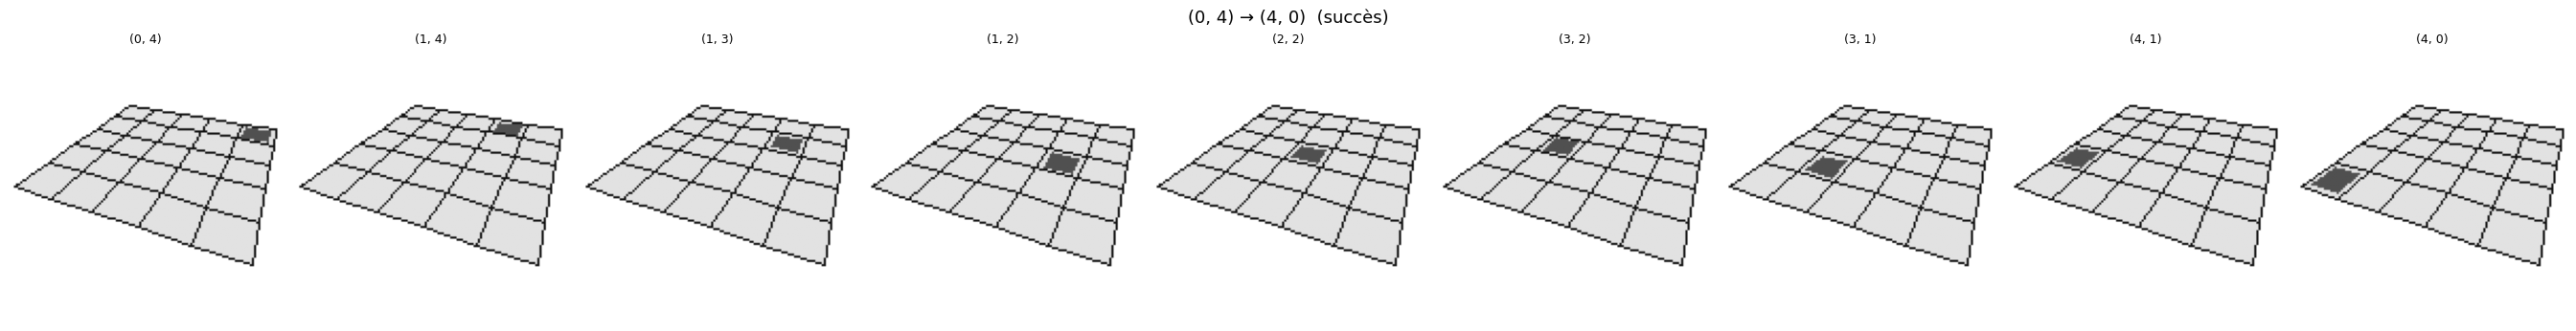

In [45]:
MY_START = (0, 4)
MY_GOAL  = (4, 0)

print(f"Planification : {MY_START} → {MY_GOAL}")
my_traj = mpc_probe(MY_START, MY_GOAL)

positions = my_traj["positions"]
n = len(positions)
fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.5))
if n == 1:
    axes = [axes]

for i, pos in enumerate(positions):
    img = render_obs(agent_pos=pos, target_pos=MY_GOAL, cache=render_cache)
    axes[i].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[i].set_title(f"{pos}", fontsize=9)
    axes[i].axis("off")

success = positions[-1] == MY_GOAL
color = "green" if success else "red"
for spine in axes[-1].spines.values():
    spine.set_edgecolor(color); spine.set_linewidth(3)

plt.suptitle(f"{MY_START} → {MY_GOAL}  ({'succès' if success else 'échec'})", fontsize=13)
plt.tight_layout()
plt.show()

## 11. Test systématique : toutes les paires de coins

On teste les 4 coins du gridworld comme départs et arrivées — les trajets les plus longs possibles.
C'est le test de robustesse du planificateur.

In [46]:
corners = [(0,0), (4,0), (0,4), (4,4)]
names   = {(0,0): "HG", (4,0): "HD", (0,4): "BG", (4,4): "BD"}

print(f"{'Départ':>4} → {'Objectif':>4}  {'Résultat':>10}  Pas")
print("-" * 40)

n_success = 0
n_total   = 0

for start in corners:
    for goal in corners:
        if start == goal:
            continue
        t = mpc_probe(start, goal, verbose=False)
        success = t["positions"][-1] == goal
        n_steps = len(t["actions"])
        n_success += int(success)
        n_total   += 1
        print(
            f"  {names[start]:>2} → {names[goal]:>2}  "
            f"{'SUCCÈS ✓' if success else 'ÉCHEC  ✗':>10}  {n_steps:>3} pas"
        )

print()
print(f"Score : {n_success}/{n_total}")

Départ → Objectif    Résultat  Pas
----------------------------------------
  HG → HD    SUCCÈS ✓    4 pas
  HG → BG    ÉCHEC  ✗   20 pas
  HG → BD    SUCCÈS ✓    8 pas
  HD → HG    SUCCÈS ✓    4 pas
  HD → BG    SUCCÈS ✓    8 pas
  HD → BD    SUCCÈS ✓    4 pas
  BG → HG    SUCCÈS ✓    4 pas
  BG → HD    SUCCÈS ✓    8 pas
  BG → BD    SUCCÈS ✓    4 pas
  BD → HG    SUCCÈS ✓    8 pas
  BD → HD    SUCCÈS ✓    4 pas
  BD → BG    SUCCÈS ✓    4 pas

Score : 11/12
